# 0. Setup

In [3]:
from google.colab import drive
import os
import glob
import re
import pandas as pd


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project

if not os.path.exists('SRSNet'):
    !git clone https://github.com/decisionintelligence/SRSNet.git
    print("代码克隆成功！")
else:
    print("代码已经存在，无需重复克隆。")

%cd SRSNet

/content/drive/MyDrive/DSAA5013_G10_Project
代码已经存在，无需重复克隆。
/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet


In [4]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.5/760.5 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/dataset

!unzip forecasting.zip

!ls

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: __MACOSX/forecasting/._m4_yearly_dataset_7150.csv  
  inflating: forecasting/m4_quarterly_dataset_17435.csv  
  inflating: __MACOSX/forecasting/._m4_quarterly_dataset_17435.csv  
  inflating: forecasting/m4_monthly_dataset_37976.csv  
  inflating: __MACOSX/forecasting/._m4_monthly_dataset_37976.csv  
  inflating: forecasting/m4_yearly_dataset_2028.csv  
  inflating: __MACOSX/forecasting/._m4_yearly_dataset_2028.csv  
  inflating: forecasting/m3_other_dataset_88.csv  
  inflating: __MACOSX/forecasting/._m3_other_dataset_88.csv  
  inflating: forecasting/m4_monthly_dataset_2052.csv  
  inflating: __MACOSX/forecasting/._m4_monthly_dataset_2052.csv  
  inflating: forecasting/m4_weekly_dataset_30.csv  
  inflating: __MACOSX/forecasting/._m4_weekly_dataset_30.csv  
  inflating: forecasting/m4_quarterly_dataset_11722.csv  
  inflating: __MACOSX/forecasting/._m4_quarterly_dataset_11722.csv  
  inflating: forecasting/m4_daily_dataset_756.csv  
  inflating

In [5]:
!pip install "numpy<2.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have nump

In [ ]:
import os
import glob
import re

# 1. 定义你要修改的脚本所在的根目录
# 如果你想修改所有数据集的 SRSNet 脚本，就指向整个 multivariate_forecast 文件夹
scripts_dir = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/scripts/multivariate_forecast/"

# 2. 找到所有子文件夹下的 SRSNet.sh (或者你想改所有的 .sh 文件也可以)
# 这里以修改所有的 .sh 文件为例，一劳永逸
sh_files = glob.glob(os.path.join(scripts_dir, "**", "*.sh"), recursive=True)

if not sh_files:
    print("没有找到 .sh 文件，请检查路径是否正确！")
else:
    modified_count = 0
    for file_path in sh_files:
        try:
            # 读取原始文件内容
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()

            # 使用正则表达式进行替换：
            # 1. 把 --gpus 后面跟着的任何数字（1, 2, 3...）全部替换成 --gpus 0
            new_content = re.sub(r'--gpus\s+\d+', '--gpus 0', content)

            # 2. 把行尾的 & 符号去掉（处理掉空格和换行前可能存在的 &）
            new_content = re.sub(r'\s*&\s*\n', '\n', new_content)
            # 处理文件最后一行可能带有的 &（没有换行符的情况）
            new_content = re.sub(r'\s*&$', '', new_content)

            # 如果内容发生了变化，就写回文件
            if content != new_content:
                with open(file_path, 'w', encoding='utf-8') as f:
                    f.write(new_content)
                modified_count += 1
                print(f"已修复: {os.path.basename(os.path.dirname(file_path))}/{os.path.basename(file_path)}")

        except Exception as e:
            print(f"处理文件 {file_path} 时出错: {e}")

    print(f"\n✅ 批量修改完成！共修复了 {modified_count} 个脚本文件。")

已修复: AQShunyi_script/PatchMLP.sh
已修复: AQShunyi_script/SRSNet.sh
已修复: AQShunyi_script/xPatch.sh
已修复: AQWan_script/PatchMLP.sh
已修复: AQWan_script/SRSNet.sh
已修复: AQWan_script/xPatch.sh
已修复: ETTh1_script/Crossformer.sh
已修复: ETTh1_script/PatchMLP.sh
已修复: ETTh1_script/PatchTST.sh
已修复: ETTh1_script/xPatch.sh
已修复: ETTh2_script/PatchTST.sh
已修复: ETTh2_script/SRSNet.sh
已修复: ETTm1_script/PatchTST.sh
已修复: ETTm1_script/SRSNet.sh
已修复: ETTm2_script/Crossformer.sh
已修复: ETTm2_script/PatchMLP.sh
已修复: ETTm2_script/PatchTST.sh
已修复: ETTm2_script/SRSNet.sh
已修复: ETTm2_script/xPatch.sh
已修复: Electricity_script/SRSNet.sh
已修复: NASDAQ_script/PatchMLP.sh
已修复: NASDAQ_script/SRSNet.sh
已修复: NASDAQ_script/xPatch.sh
已修复: NYSE_script/PatchMLP.sh
已修复: NYSE_script/SRSNet.sh
已修复: NYSE_script/xPatch.sh
已修复: PEMS08_script/PatchMLP.sh
已修复: PEMS08_script/SRSNet.sh
已修复: PEMS08_script/xPatch.sh
已修复: Solar_script/Crossformer.sh
已修复: Solar_script/PatchMLP.sh
已修复: Solar_script/PatchTST.sh
已修复: Solar_script/SRSNet.sh
已修复: Solar_script

# 1. SRSNet

## 1.1 ETTh1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 09:50:28 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 09:50:29 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 09:50:29 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 09:50:29 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 09:50:29 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 09:50:29 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 09:50:29 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 09:50:29 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.366 0.394
  ETTh1      192 0.400 0.416
  ETTh1      336 0.425 0.431
  ETTh1      720 0.427 0.456

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/SRSNet/ETTh1_Final_Summary.csv


## 1.2 ETTh2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh2_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 10:26:08 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 10:26:08 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 10:26:08 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 10:26:08 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 10:26:08 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 10:26:08 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 10:26:08 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 10:26:09 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh2_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh2       96 0.275 0.340
  ETTh2      192 0.334 0.380
  ETTh2      336 0.352 0.396
  ETTh2      720 0.410 0.445

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/SRSNet/ETTh2_Final_Summary.csv


## 1.3 ETTm1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm1_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 10:34:44 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 10:34:45 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 10:34:45 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 10:34:45 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 10:34:45 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 10:34:45 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 10:34:45 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 10:34:45 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTm1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTm1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm1       96 0.288 0.341
  ETTm1      192 0.328 0.367
  ETTm1      336 0.366 0.393
  ETTm1      720 0.435 0.425

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/SRSNet/ETTm1_Final_Summary.csv


## 1.4 ETTm2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 11:02:14 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 11:02:14 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 11:02:14 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 11:02:14 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 11:02:14 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 11:02:14 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 11:02:14 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 11:02:15 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTm2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm2_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTm2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm2       96 0.164 0.254
  ETTm2      192 0.224 0.298
  ETTm2      336 0.275 0.329
  ETTm2      720 0.355 0.383

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/SRSNet/ETTm2_Final_Summary.csv


## 1.5 Weather

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Weather_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 11:21:59 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 11:22:00 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 11:22:00 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 11:22:00 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 11:22:00 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 11:22:00 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 11:22:00 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 11:22:01 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Weather",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Weather_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

Dataset  Horizon   MSE   MAE
Weather       96 0.149 0.202
Weather      192 0.193 0.243
Weather      336 0.244 0.284
Weather      720 0.320 0.337

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/SRSNet/Weather_Final_Summary.csv


## 1.6 Electricity

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Electricity_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 12:14:14 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 12:14:20 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 12:14:20 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 12:14:20 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 12:14:20 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 12:14:20 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 12:14:20 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 12:14:21 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Electricity",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== Electricity 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Electricity_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Electricity 最终结果汇总 ======

    Dataset  Horizon   MSE   MAE
Electricity       96 0.131 0.226
Electricity      192 0.148 0.241
Electricity      336 0.164 0.258
Electricity      720 0.201 0.291

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/SRSNet/Electricity_Final_Summary.csv


## 1.7 Solar

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Solar_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 14:17:01 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 14:17:12 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 14:17:12 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 14:17:12 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 14:17:12 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 14:17:12 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 14:17:12 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 14:17:13 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Solar",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== Solar 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Solar_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Solar 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  Solar       96 0.167 0.221
  Solar      192 0.183 0.238
  Solar      336 0.190 0.245
  Solar      720 0.196 0.252

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/SRSNet/Solar_Final_Summary.csv


## 1.8 Traffic

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Traffic_script/SRSNet.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-16 16:09:11 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-16 16:09:29 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-16 16:09:29 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-16 16:09:29 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-16 16:09:29 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-16 16:09:29 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-16 16:09:29 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-16 16:09:30 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.
------------

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/SRSNet/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Traffic",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== Traffic 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Traffic_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Traffic 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Traffic       96 0.361 0.254
Traffic      192 0.380 0.263
Traffic      336 0.392 0.270
Traffic      720 0.434 0.293

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/SRSNet/Traffic_Final_Summary.csv


## 1.9 Result

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/SRSnet"

all_files = glob.glob(os.path.join(folder_path, "*_Final_Summary.csv"))

if not all_files:
    print("没有找到文件，请检查文件夹路径是否完全正确！")
else:
    df_list = []

    for file in all_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"读取 {os.path.basename(file)} 时出错: {e}")

    final_df = pd.concat(df_list, ignore_index=True)

    dataset_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'Weather', 'Electricity', 'Solar', 'Traffic']

    final_df['Dataset'] = pd.Categorical(final_df['Dataset'], categories=dataset_order, ordered=True)

    final_df = final_df.sort_values(by=['Dataset', 'Horizon']).reset_index(drop=True)

    print(final_df.to_string(index=False))

    csv_save_path = os.path.join(folder_path, "SRSNet_All_Results_Summary.csv")
    final_df.to_csv(csv_save_path, index=False)

    excel_save_path = os.path.join(folder_path, "SRSNet_All_Results_Summary.xlsx")
    final_df.to_excel(excel_save_path, index=False)

没有找到文件，请检查文件夹路径是否完全正确！


# 2. iTransformer

## 2.1 ETTh1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 15:31:22 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 15:31:22 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 15:31:22 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 15:31:22 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 15:31:22 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 15:31:22 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 15:31:22 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 15:31:56 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh1_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.386 0.405
  ETTh1      192 0.424 0.440
  ETTh1      336 0.454 0.456
  ETTh1      720 0.488 0.482

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/iTransformer/ETTh1_Final_Summary_iTransformer.csv


## 2.2 ETTh2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh2_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 15:39:27 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 15:39:28 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 15:39:28 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 15:39:28 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 15:39:28 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 15:39:28 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 15:39:28 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 15:39:29 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer ETTh2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh2_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer ETTh2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh2       96 0.297 0.348
  ETTh2      192 0.372 0.403
  ETTh2      336 0.388 0.417
  ETTh2      720 0.424 0.444

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/iTransformer/ETTh2_Final_Summary_iTransformer.csv


## 2.3 ETTm1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm1_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 15:43:36 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 15:43:37 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 15:43:37 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 15:43:37 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 15:43:37 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 15:43:37 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 15:43:37 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 15:43:38 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer ETTm1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm1_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer ETTm1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm1       96 0.300 0.353
  ETTm1      192 0.341 0.380
  ETTm1      336 0.374 0.396
  ETTm1      720 0.429 0.430

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/iTransformer/ETTm1_Final_Summary_iTransformer.csv


## 2.4 ETTm2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 15:52:38 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 15:52:40 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 15:52:40 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 15:52:40 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 15:52:40 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 15:52:40 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 15:52:40 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 15:52:41 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer ETTm2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm2_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer ETTm2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm2       96 0.175 0.266
  ETTm2      192 0.242 0.312
  ETTm2      336 0.282 0.337
  ETTm2      720 0.375 0.394

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/iTransformer/ETTm2_Final_Summary_iTransformer.csv


## 2.5 Weather

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Weather_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 16:00:51 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 16:00:53 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 16:00:53 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 16:00:53 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 16:00:53 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 16:00:53 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 16:00:53 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 16:00:54 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Weather",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer Weather 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Weather_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer Weather 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Weather       96 0.157 0.207
Weather      192 0.200 0.248
Weather      336 0.252 0.287
Weather      720 0.320 0.336

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/iTransformer/Weather_Final_Summary_iTransformer.csv


## 2.6 Electricity

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Electricity_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 16:13:06 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 16:13:16 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 16:13:16 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 16:13:16 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 16:13:16 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 16:13:16 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 16:13:16 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 16:13:17 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Electricity",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer Electricity 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Electricity_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer Electricity 最终结果汇总 ======

    Dataset  Horizon   MSE   MAE
Electricity       96 0.134 0.230
Electricity      192 0.154 0.250
Electricity      336 0.169 0.265
Electricity      720 0.194 0.288

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/iTransformer/Electricity_Final_Summary_iTransformer.csv


## 2.7 Solar

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Solar_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 16:57:14 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 16:57:21 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 16:57:21 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 16:57:21 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 16:57:21 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 16:57:21 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 16:57:21 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 16:57:22 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Solar",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer Solar 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Solar_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer Solar 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  Solar       96 0.189 0.244
  Solar      192 0.193 0.257
  Solar      336 0.200 0.262
  Solar      720 0.223 0.281

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/iTransformer/Solar_Final_Summary_iTransformer.csv


## 2.8 *Traffic*

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Traffic_script/iTransformer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 17:44:41 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 17:44:55 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 17:44:55 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 17:44:55 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 17:44:55 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 17:44:55 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 17:44:55 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.iTransformer
scheduling iTransformer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 17:44:56 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please u

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/iTransformer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Traffic",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== iTransformer Traffic 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Traffic_Final_Summary_iTransformer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== iTransformer Traffic 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Traffic       96 0.363 0.265
Traffic      192 0.384 0.273
Traffic      336 0.396 0.277
Traffic      720 0.445 0.308

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/iTransformer/Traffic_Final_Summary_iTransformer.csv


## 2.9 Result

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/iTransformer"

all_files = glob.glob(os.path.join(folder_path, "*_Final_Summary_iTransformer.csv"))

if not all_files:
    print("没有找到文件，请检查文件夹路径是否完全正确！")
else:
    df_list = []

    for file in all_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"读取 {os.path.basename(file)} 时出错: {e}")

    final_df = pd.concat(df_list, ignore_index=True)

    dataset_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'Weather', 'Electricity', 'Solar', 'Traffic']

    final_df['Dataset'] = pd.Categorical(final_df['Dataset'], categories=dataset_order, ordered=True)

    final_df = final_df.sort_values(by=['Dataset', 'Horizon']).reset_index(drop=True)

    print(final_df.to_string(index=False))

    csv_save_path = os.path.join(folder_path, "iTransformer_All_Results_Summary.csv")
    final_df.to_csv(csv_save_path, index=False)

    excel_save_path = os.path.join(folder_path, "iTransformer_All_Results_Summary.xlsx")
    final_df.to_excel(excel_save_path, index=False)

    Dataset  Horizon   MSE   MAE
      ETTh1       96 0.386 0.405
      ETTh1      192 0.424 0.440
      ETTh1      336 0.454 0.456
      ETTh1      720 0.488 0.482
      ETTh2       96 0.297 0.348
      ETTh2      192 0.372 0.403
      ETTh2      336 0.388 0.417
      ETTh2      720 0.424 0.444
      ETTm1       96 0.300 0.353
      ETTm1      192 0.341 0.380
      ETTm1      336 0.374 0.396
      ETTm1      720 0.429 0.430
      ETTm2       96 0.175 0.266
      ETTm2      192 0.242 0.312
      ETTm2      336 0.282 0.337
      ETTm2      720 0.375 0.394
    Weather       96 0.157 0.207
    Weather      192 0.200 0.248
    Weather      336 0.252 0.287
    Weather      720 0.320 0.336
Electricity       96 0.134 0.230
Electricity      192 0.154 0.250
Electricity      336 0.169 0.265
Electricity      720 0.194 0.288
      Solar       96 0.189 0.244
      Solar      192 0.193 0.257
      Solar      336 0.200 0.262
      Solar      720 0.223 0.281
    Traffic       96 0.363 0.265
    Traffi

# 3. TimeMixer

## 3.1 ETTh1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 18:41:21 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 18:41:22 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 18:41:22 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 18:41:22 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 18:41:22 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 18:41:22 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 18:41:22 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 18:41:22 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh1_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== TimeMixer ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.386 0.416
  ETTh1      192 0.440 0.443
  ETTh1      336 0.435 0.443
  ETTh1      720 0.477 0.488

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/TimeMixer/ETTh1_Final_Summary_TimeMixer.csv


## 3.2 ETTh2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh2_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 18:56:46 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 18:56:46 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 18:56:46 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 18:56:46 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 18:56:46 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 18:56:46 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 18:56:46 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 18:56:48 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer ETTh2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh2_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== TimeMixer ETTh2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh2       96 0.287 0.354
  ETTh2      192 0.349 0.387
  ETTh2      336 0.398 0.429
  ETTh2      720 0.401 0.436

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/TimeMixer/ETTh2_Final_Summary_TimeMixer.csv


## 3.3 ETTm1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm1_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 19:13:33 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 19:13:34 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 19:13:34 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 19:13:34 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 19:13:34 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 19:13:34 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 19:13:34 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 19:13:35 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer ETTm1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm1_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== TimeMixer ETTm1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm1       96 0.293 0.345
  ETTm1      192 0.335 0.372
  ETTm1      336 0.368 0.386
  ETTm1      720 0.426 0.417

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/TimeMixer/ETTm1_Final_Summary_TimeMixer.csv


## 3.4 ETTm2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 19:58:35 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 19:58:35 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 19:58:35 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 19:58:35 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 19:58:35 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 19:58:35 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 19:58:35 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 19:58:36 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer ETTm2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm2_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== TimeMixer ETTm2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm2       96 0.165 0.256
  ETTm2      192 0.225 0.298
  ETTm2      336 0.277 0.332
  ETTm2      720 0.360 0.387

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/TimeMixer/ETTm2_Final_Summary_TimeMixer.csv


## 3.5 Weather

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Weather_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-17 20:37:06 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-17 20:37:07 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-17 20:37:07 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-17 20:37:07 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-17 20:37:07 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-17 20:37:07 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-17 20:37:07 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-17 20:37:08 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Weather",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer Weather 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Weather_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== TimeMixer Weather 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Weather       96 0.148 0.198
Weather      192 0.193 0.244
Weather      336 0.247 0.284
Weather      720 0.318 0.336

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/TimeMixer/Weather_Final_Summary_TimeMixer.csv


## 3.6 Electricity

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Electricity_script/TimeMixer.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-20 19:52:17 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-20 19:52:28 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-20 19:52:28 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-20 19:52:28 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-20 19:52:28 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-20 19:52:28 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-20 19:52:28 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.time_series_library.TimeMixer
scheduling TimeMixer:   0% 0/1 [00:00<?, ?it/s]2026-05-20 19:52:29 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Electricity",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer Electricity 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Electricity_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

## 3.7 Solar

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Solar_script/TimeMixer.sh

[Errno 2] No such file or directory: '/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet'
/content
bash: ./scripts/multivariate_forecast/Solar_script/TimeMixer.sh: No such file or directory


In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Solar",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer Solar 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Solar_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

## 3.8 Traffic

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Traffic_script/TimeMixer.sh

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/TimeMixer/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Traffic",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== TimeMixer Traffic 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Traffic_Final_Summary_TimeMixer.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

## 3.9 Result

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/TimeMixer"

all_files = glob.glob(os.path.join(folder_path, "*_Final_Summary_TimeMixer.csv"))

if not all_files:
    print("没有找到文件，请检查文件夹路径是否完全正确！")
else:
    df_list = []

    for file in all_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"读取 {os.path.basename(file)} 时出错: {e}")

    final_df = pd.concat(df_list, ignore_index=True)

    dataset_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'Weather']

    final_df['Dataset'] = pd.Categorical(final_df['Dataset'], categories=dataset_order, ordered=True)

    final_df = final_df.sort_values(by=['Dataset', 'Horizon']).reset_index(drop=True)

    print(final_df.to_string(index=False))

    csv_save_path = os.path.join(folder_path, "TimeMixer_All_Results_Summary.csv")
    final_df.to_csv(csv_save_path, index=False)

    excel_save_path = os.path.join(folder_path, "TimeMixer_All_Results_Summary.xlsx")
    final_df.to_excel(excel_save_path, index=False)

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.386 0.416
  ETTh1      192 0.440 0.443
  ETTh1      336 0.435 0.443
  ETTh1      720 0.477 0.488
  ETTh2       96 0.287 0.354
  ETTh2      192 0.349 0.387
  ETTh2      336 0.398 0.429
  ETTh2      720 0.401 0.436
  ETTm1       96 0.293 0.345
  ETTm1      192 0.335 0.372
  ETTm1      336 0.368 0.386
  ETTm1      720 0.426 0.417
  ETTm2       96 0.165 0.256
  ETTm2      192 0.225 0.298
  ETTm2      336 0.277 0.332
  ETTm2      720 0.360 0.387
Weather       96 0.148 0.198
Weather      192 0.193 0.244
Weather      336 0.247 0.284
Weather      720 0.318 0.336


# 4. Amplifier

In [ ]:
# 1. 定义包含所有数据集脚本的根目录
base_dir = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/scripts/multivariate_forecast/"

# 2. 找到所有子文件夹下的 SRSNet.sh 作为模板
# 假设你之前已经把它们都修复成了单卡串行模式
srsnet_scripts = glob.glob(os.path.join(base_dir, "**", "SRSNet.sh"), recursive=True)

if not srsnet_scripts:
    print("没有找到 SRSNet.sh 模板文件，请检查路径。")
else:
    success_count = 0
    for src_file in srsnet_scripts:
        # 目标文件名为 Amplifier.sh，和 SRSNet.sh 放在同一个文件夹里
        target_file = os.path.join(os.path.dirname(src_file), "Amplifier.sh")
        folder_name = os.path.basename(os.path.dirname(src_file)) # 例如 ETTh1_script

        try:
            # 读取模板内容
            with open(src_file, 'r', encoding='utf-8') as f:
                content = f.read()

            # ===== 核心替换逻辑 =====

            # 1. 替换模型名称为 Amplifier
            content = content.replace('--model-name "srsnet.SRSNet"', '--model-name "amplifier.amplifier.Amplifier"')

            # 2. 移除 SRSNet 专属的超参数，让底层读取 Amplifier 默认配置
            content = re.sub(r"--model-hyper-params\s+'\{.*?\}'", "", content)

            # 3. 替换保存路径 (把类似 "ETTh1/SRSNet" 变成 "ETTh1/Amplifier")
            # 通过匹配 /SRSNet" 来安全替换
            content = content.replace('/SRSNet"', '/Amplifier"')

            # ========================

            # 保存为新的 Amplifier.sh
            with open(target_file, 'w', encoding='utf-8') as f:
                f.write(content)

            print(f"✅ 成功生成: {folder_name}/Amplifier.sh")
            success_count += 1

        except Exception as e:
            print(f"❌ 生成 {folder_name}/Amplifier.sh 时出错: {e}")

    print(f"\n🎉 批量生成完毕！共成功定制了 {success_count} 个专属脚本！")

✅ 成功生成: Electricity_script/Amplifier.sh
✅ 成功生成: AQShunyi_script/Amplifier.sh
✅ 成功生成: AQWan_script/Amplifier.sh
✅ 成功生成: ETTh1_script/Amplifier.sh
✅ 成功生成: ETTh2_script/Amplifier.sh
✅ 成功生成: ETTm1_script/Amplifier.sh
✅ 成功生成: ETTm2_script/Amplifier.sh
✅ 成功生成: NASDAQ_script/Amplifier.sh
✅ 成功生成: NYSE_script/Amplifier.sh
✅ 成功生成: PEMS08_script/Amplifier.sh
✅ 成功生成: Solar_script/Amplifier.sh
✅ 成功生成: Traffic_script/Amplifier.sh
✅ 成功生成: Weather_script/Amplifier.sh
✅ 成功生成: ZafNoo_script/Amplifier.sh

🎉 批量生成完毕！共成功定制了 14 个专属脚本！


In [ ]:
# 1. 定义包含所有脚本的根目录
base_dir = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/scripts/multivariate_forecast/"

# 2. 找到所有的 Amplifier.sh
amplifier_scripts = glob.glob(os.path.join(base_dir, "**", "Amplifier.sh"), recursive=True)

if not amplifier_scripts:
    print("没有找到 Amplifier.sh 文件！请检查之前的生成步骤。")
else:
    success_count = 0

    # 3. 论文复现的“黄金超参数”
    # 我们把学习率 lr 压到 0.0001，seq_len 设为论文附录提到的 336
    tuned_params = '--model-hyper-params \'{"lr": 0.0001, "batch_size": 32, "seq_len": 336, "hidden_size": 128, "patience": 3}\''
    target_model_str = '--model-name "amplifier.amplifier.Amplifier"'

    for filepath in amplifier_scripts:
        folder_name = os.path.basename(os.path.dirname(filepath))
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()

            # 第一步：安全起见，用正则表达式先清洗掉可能存在的旧超参数 (防止重复注入)
            content = re.sub(r"--model-hyper-params\s+'\{.*?\}'\s*", "", content)

            # 第二步：在 model-name 后面，强行注入我们的黄金超参数
            content = content.replace(target_model_str, f"{target_model_str} {tuned_params} ")

            # 第三步：写回文件
            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(content)

            print(f"✅ 成功注入调优参数: {folder_name}/Amplifier.sh")
            success_count += 1

        except Exception as e:
            print(f"❌ 修改 {folder_name}/Amplifier.sh 时出错: {e}")

    print(f"\n🎉 批量调优修改完毕！共更新了 {success_count} 个数据集的脚本！")

✅ 成功注入调优参数: Electricity_script/Amplifier.sh
✅ 成功注入调优参数: AQShunyi_script/Amplifier.sh
✅ 成功注入调优参数: AQWan_script/Amplifier.sh
✅ 成功注入调优参数: ETTh1_script/Amplifier.sh
✅ 成功注入调优参数: ETTh2_script/Amplifier.sh
✅ 成功注入调优参数: ETTm1_script/Amplifier.sh
✅ 成功注入调优参数: ETTm2_script/Amplifier.sh
✅ 成功注入调优参数: NASDAQ_script/Amplifier.sh
✅ 成功注入调优参数: NYSE_script/Amplifier.sh
✅ 成功注入调优参数: PEMS08_script/Amplifier.sh
✅ 成功注入调优参数: Solar_script/Amplifier.sh
✅ 成功注入调优参数: Traffic_script/Amplifier.sh
✅ 成功注入调优参数: Weather_script/Amplifier.sh
✅ 成功注入调优参数: ZafNoo_script/Amplifier.sh

🎉 批量调优修改完毕！共更新了 14 个数据集的脚本！


## 4.1 ETTh1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-20 18:27:53 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-20 18:27:53 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-20 18:27:53 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-20 18:27:53 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-20 18:27:53 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-20 18:27:53 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-20 18:27:53 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-20 18:27:54 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh1_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.419 0.425
  ETTh1      192 0.464 0.451
  ETTh1      336 0.461 0.455
  ETTh1      720 0.526 0.515

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Amplifier/ETTh1_Final_Summary_Amplifier.csv


## 4.2 ETTh2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh2_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-20 18:32:13 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-20 18:32:15 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-20 18:32:15 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-20 18:32:15 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-20 18:32:15 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-20 18:32:15 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-20 18:32:15 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-20 18:32:16 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier ETTh2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTh2_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier ETTh2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh2       96 0.330 0.386
  ETTh2      192 0.374 0.412
  ETTh2      336 0.386 0.421
  ETTh2      720 0.429 0.454

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh2/Amplifier/ETTh2_Final_Summary_Amplifier.csv


## 4.3 ETTm1

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm1_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 13:35:15 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 13:35:17 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 13:35:17 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 13:35:17 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 13:35:17 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 13:35:17 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 13:35:17 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 13:35:18 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier ETTm1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm1_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier ETTm1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm1       96 1.374 0.750
  ETTm1      192 1.380 0.756
  ETTm1      336 0.373 0.390
  ETTm1      720 0.432 0.427

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm1/Amplifier/ETTm1_Final_Summary_Amplifier.csv


## 4.4 ETTm2

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 13:45:58 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 13:46:00 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 13:46:00 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 13:46:00 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 13:46:00 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 13:46:00 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 13:46:00 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 13:46:01 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTm2",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier ETTm2 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "ETTm2_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier ETTm2 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTm2       96 0.301 0.377
  ETTm2      192 0.339 0.397
  ETTm2      336 0.282 0.335
  ETTm2      720 0.383 0.403

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTm2/Amplifier/ETTm2_Final_Summary_Amplifier.csv


## 4.5 Weather

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Weather_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 13:55:42 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 13:55:44 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 13:55:44 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 13:55:44 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 13:55:44 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 13:55:44 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 13:55:44 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 13:55:45 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Weather",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier Weather 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Weather_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier Weather 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Weather       96 0.254 0.311
Weather      192 0.217 0.265
Weather      336 0.253 0.287
Weather      720 0.325 0.336

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Weather/Amplifier/Weather_Final_Summary_Amplifier.csv


## 4.6 Electricity

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Electricity_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 17:02:23 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 17:02:32 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 17:02:32 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 17:02:32 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 17:02:32 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 17:02:32 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 17:02:32 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 17:03:13 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Electricity",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier Electricity 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Electricity_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier Electricity 最终结果汇总 ======

    Dataset  Horizon   MSE   MAE
Electricity       96 0.261 0.324
Electricity      192 0.223 0.306
Electricity      336 0.188 0.290
Electricity      720 0.302 0.367

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Electricity/Amplifier/Electricity_Final_Summary_Amplifier.csv


## 4.7 Solar

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Solar_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 17:33:18 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 17:33:27 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 17:33:27 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 17:33:27 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 17:33:27 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 17:33:27 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 17:33:27 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 17:33:28 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Solar",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier Solar 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Solar_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier Solar 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  Solar       96 1.746 0.999
  Solar      192 0.256 0.286
  Solar      336 0.251 0.282
  Solar      720 0.263 0.297

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Solar/Amplifier/Solar_Final_Summary_Amplifier.csv


## 4.8 Traffic

In [ ]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/Traffic_script/Amplifier.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-19 18:36:54 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-19 18:37:08 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-19 18:37:08 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-19 18:37:08 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-19 18:37:08 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-19 18:37:08 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-19 18:37:08 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.amplifier.amplifier.Amplifier
scheduling Amplifier:   0% 0/1 [00:00<?, ?it/s]2026-05-19 18:37:09 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pre

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/Amplifier/"
csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请检查路径。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            strategy_str = str(df.iloc[0, 0])
            match = re.search(r'"horizon":\s*(\d+)', strategy_str)
            horizon = int(match.group(1)) if match else 0

            data_col = df.columns[2]
            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "Traffic",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)
        print("====== Amplifier Traffic 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Traffic_Final_Summary_Amplifier.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== Amplifier Traffic 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
Traffic       96 1.002 0.537
Traffic      192 0.634 0.422
Traffic      336 0.497 0.365
Traffic      720 0.841 0.495

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/Traffic/Amplifier/Traffic_Final_Summary_Amplifier.csv


## 4.9 Result

In [ ]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/Amplifier"

all_files = glob.glob(os.path.join(folder_path, "*_Final_Summary_Amplifier.csv"))

if not all_files:
    print("没有找到文件，请检查文件夹路径是否完全正确！")
else:
    df_list = []

    for file in all_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"读取 {os.path.basename(file)} 时出错: {e}")

    final_df = pd.concat(df_list, ignore_index=True)

    dataset_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'Weather', 'Electricity', 'Solar', 'Traffic']

    final_df['Dataset'] = pd.Categorical(final_df['Dataset'], categories=dataset_order, ordered=True)

    final_df = final_df.sort_values(by=['Dataset', 'Horizon']).reset_index(drop=True)

    print(final_df.to_string(index=False))

    csv_save_path = os.path.join(folder_path, "Amplifier_All_Results_Summary.csv")
    final_df.to_csv(csv_save_path, index=False)

    excel_save_path = os.path.join(folder_path, "Amplifier_All_Results_Summary.xlsx")
    final_df.to_excel(excel_save_path, index=False)

    Dataset  Horizon   MSE   MAE
      ETTh1       96 0.419 0.425
      ETTh1      192 0.464 0.451
      ETTh1      336 0.461 0.455
      ETTh1      720 0.526 0.515
      ETTh2       96 0.330 0.386
      ETTh2      192 0.374 0.412
      ETTh2      336 0.386 0.421
      ETTh2      720 0.429 0.454
      ETTm1       96 1.374 0.750
      ETTm1      192 1.380 0.756
      ETTm1      336 0.373 0.390
      ETTm1      720 0.432 0.427
      ETTm2       96 0.301 0.377
      ETTm2      192 0.339 0.397
      ETTm2      336 0.282 0.335
      ETTm2      720 0.383 0.403
    Weather       96 0.254 0.311
    Weather      192 0.217 0.265
    Weather      336 0.253 0.287
    Weather      720 0.325 0.336
Electricity       96 0.261 0.324
Electricity      192 0.223 0.306
Electricity      336 0.188 0.290
Electricity      720 0.302 0.367
      Solar       96 1.746 0.999
      Solar      192 0.256 0.286
      Solar      336 0.251 0.282
      Solar      720 0.263 0.297
    Traffic       96 1.002 0.537
    Traffi

# 5. Ablation Study and Analysis

In [13]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

# ==========================================
# 实验 1：w/o Selective Patching (去掉选择机制)
# ==========================================
!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 96}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_selective_patching": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 96, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Selection"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 192}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_selective_patching": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 192, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Selection"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 336}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_selective_patching": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 336, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Selection"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 720}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_selective_patching": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 720, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Selection"


/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 10:55:14 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 10:55:14 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 10:55:14 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 10:55:14 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 10:55:14 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 10:55:14 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 10:55:14 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 10:55:15 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [14]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Selection/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Ablation_wo_Selection_ETTh1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.365 0.392
  ETTh1      192 0.402 0.415
  ETTh1      336 0.425 0.430
  ETTh1      720 0.452 0.467

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Selection/Ablation_wo_Selection_ETTh1_Final_Summary.csv


In [15]:
# ==========================================
# 实验 2：w/o Dynamic Reassembly (去掉重组机制)
# ==========================================
!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 96}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_dynamic_reassembly": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 96, "lradj": "type1", "patch_len": 18, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Reassembly"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 192}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_dynamic_reassembly": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 192, "lradj": "type1", "patch_len": 18, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Reassembly"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 336}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_dynamic_reassembly": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 336, "lradj": "type1", "patch_len": 18, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Reassembly"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 720}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_dynamic_reassembly": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 720, "lradj": "type1", "patch_len": 18, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Reassembly"

2026-05-22 11:00:37 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 11:00:37 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 11:00:37 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 11:00:37 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 11:00:37 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 11:00:37 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 11:00:37 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 11:00:38 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当前强行焊死的开关状态：
use_srs: True
use_selective_patching: T

In [16]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Reassembly/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Ablation_wo_Reassembly_ETTh1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.372 0.400
  ETTh1      192 0.411 0.426
  ETTh1      336 0.436 0.443
  ETTh1      720 0.460 0.476

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Reassembly/Ablation_wo_Reassembly_ETTh1_Final_Summary.csv


In [17]:
# ==========================================
# 实验 3：w/o Adaptive Fusion (去掉自适应融合)
# ==========================================
!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 96}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_adaptive_fusion": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 96, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Fusion"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 192}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_adaptive_fusion": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 192, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Fusion"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 336}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_adaptive_fusion": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 336, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Fusion"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 720}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_adaptive_fusion": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 720, "lradj": "type1", "patch_len": 24, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 4 --timeout 60000 --save-path "ETTh1/Ablation_wo_Fusion"

2026-05-22 11:05:22 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 11:05:23 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 11:05:23 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 11:05:23 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 11:05:23 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 11:05:23 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 11:05:23 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 11:05:24 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当前强行焊死的开关状态：
use_srs: True
use_selective_patching: T

In [18]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Fusion/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "Ablation_wo_Fusion_ETTh1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.387 0.417
  ETTh1      192 0.433 0.448
  ETTh1      336 0.479 0.480
  ETTh1      720 0.526 0.521

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_Fusion/Ablation_wo_Fusion_ETTh1_Final_Summary.csv


In [19]:
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
# ==========================================
# 实验 4：w/o SRS (退化为纯基线)
# ==========================================
!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 96}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_srs": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 96, "lradj": "type1", "patch_len": 14, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 1 --timeout 60000 --save-path "ETTh1/Ablation_wo_SRS"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 192}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_srs": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 192, "lradj": "type1", "patch_len": 14, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 1 --timeout 60000 --save-path "ETTh1/Ablation_wo_SRS"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 336}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_srs": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 336, "lradj": "type1", "patch_len": 14, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 1 --timeout 60000 --save-path "ETTh1/Ablation_wo_SRS"

!python ./scripts/run_benchmark.py --config-path "rolling_forecast_config.json" --data-name-list "ETTh1.csv" --strategy-args '{"horizon": 720}' --model-name "srsnet.SRSNet" --model-hyper-params '{"use_srs": false, "batch_size": 32, "d_model": 256, "alpha":3.5, "pos":false, "dropout": 0.05, "head_dropout": 0.0, "head_mode": "linear", "horizon": 720, "lradj": "type1", "patch_len": 14, "patience": 10, "seq_len": 512, "stride": 24}' --gpus 0 --num-workers 1 --timeout 60000 --save-path "ETTh1/Ablation_wo_SRS"

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 11:10:02 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 11:10:02 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 11:10:02 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 11:10:02 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 11:10:02 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 11:10:02 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 11:10:02 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 11:10:03 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [20]:
folder_path = "/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_SRS/"

csv_files = glob.glob(os.path.join(folder_path, "**", "test_report*.csv"), recursive=True)

if not csv_files:
    print("没有找到 CSV 文件，请确认你是否已经将 tar.gz 压缩包解压，或者检查路径是否正确。")
else:
    results = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)

            data_col = df.columns[2]

            match = re.search(r'"horizon":\s*(\d+)', data_col)
            horizon = int(match.group(1)) if match else 0

            mse = df.loc[df['metric_name'] == 'mse_norm', data_col].values[0]
            mae = df.loc[df['metric_name'] == 'mae_norm', data_col].values[0]

            results.append({
                "Dataset": "ETTh1",
                "Horizon": horizon,
                "MSE": round(float(mse), 3),
                "MAE": round(float(mae), 3)
            })
        except Exception as e:
            print(f"读取文件 {os.path.basename(file)} 时出错: {e}")

    if results:
        summary_df = pd.DataFrame(results).sort_values("Horizon").reset_index(drop=True)

        print("====== ETTh1 最终结果汇总 ======\n")
        print(summary_df.to_string(index=False))

        save_path = os.path.join(folder_path, "wo_SRS_ETTh1_Final_Summary.csv")
        summary_df.to_csv(save_path, index=False)
        print(f"\n✅ 汇总表格已成功保存至: {save_path}")

====== ETTh1 最终结果汇总 ======

Dataset  Horizon   MSE   MAE
  ETTh1       96 0.396 0.414
  ETTh1      192 0.431 0.437
  ETTh1      336 0.446 0.448
  ETTh1      720 0.461 0.475

✅ 汇总表格已成功保存至: /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet/result/ETTh1/Ablation_wo_SRS/wo_SRS_ETTh1_Final_Summary.csv


# 6. Parameter Sensitivity

## 6.1 ETTh1

In [22]:
#Patch Size
#(7 14 24 30)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/SRSnet_patch_len.sh


/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 13:31:22 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 13:31:22 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 13:31:22 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 13:31:22 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 13:31:22 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 13:31:22 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 13:31:22 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 13:31:23 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [23]:
#seq_len
#(192, 336, 512, 720)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/SRSnet_seq_len.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 13:37:28 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 13:37:28 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 13:37:28 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 13:37:28 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 13:37:28 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 13:37:28 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 13:37:28 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 13:37:29 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [24]:
#d_model
#(64, 128, 256, 512)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTh1_script/SRSnet_d_model.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 13:42:58 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 13:42:58 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 13:42:58 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 13:42:58 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 13:42:58 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 13:42:58 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 13:42:58 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 13:42:59 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

## 6.2 ETTm2

In [25]:
#Patch Size
#(7 14 24 30)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/SRSnet_patch_len.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 13:52:33 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 13:52:36 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 13:52:36 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 13:52:36 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 13:52:36 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 13:52:36 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 13:52:36 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 13:52:37 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [26]:
#seq_len
#(192, 336, 512, 720)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/SRSnet_seq_len.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 14:07:19 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 14:07:20 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 14:07:20 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 14:07:20 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 14:07:20 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 14:07:20 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 14:07:20 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 14:07:21 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

In [27]:
#d_model
#(64, 128, 256, 512)
%cd /content/drive/MyDrive/DSAA5013_G10_Project/SRSNet

!bash ./scripts/multivariate_forecast/ETTm2_script/SRSnet_d_model.sh

/content/drive/MyDrive/DSAA5013_G10_Project/SRSNet
2026-05-22 14:23:10 [INFO] ts_benchmark.data.data_source(126): Start loading 1 series in parallel
2026-05-22 14:23:11 [INFO] ts_benchmark.data.data_source(135): Data loading finished.
2026-05-22 14:23:11 [INFO] ts_benchmark.data.suites.global_storage(40): Data server starting...
2026-05-22 14:23:11 [INFO] ts_benchmark.data.suites.global_storage(41): Start sending data to the global storage.
2026-05-22 14:23:11 [INFO] ts_benchmark.data.suites.global_storage(46): Notifying all workers to sync data from the global storage.
2026-05-22 14:23:11 [INFO] ts_benchmark.data.suites.global_storage(49): Data server started.
2026-05-22 14:23:11 [INFO] ts_benchmark.models.model_loader(102): Trying to load model ts_benchmark.baselines.srsnet.SRSNet
scheduling SRSNet:   0% 0/1 [00:00<?, ?it/s]2026-05-22 14:23:12 [WARNING] ts_benchmark.baselines.deep_forecasting_model_base(55): The model parameter horizon is deprecated. Please use pred_len.

🚨 模型初始化成功！当

## 6.3 Plots

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

✅ 成功生成 1x3 组图并保存至: /content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/sensitivity_ALL_ETTh1.png


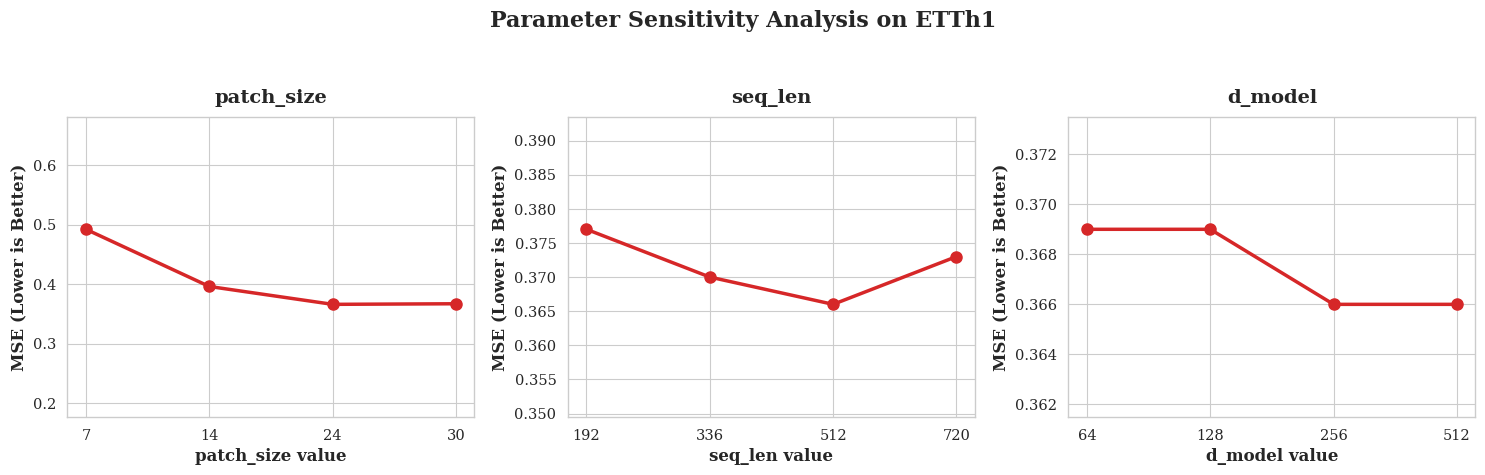

✅ 成功生成 1x3 组图并保存至: /content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/sensitivity_ALL_ETTm2.png


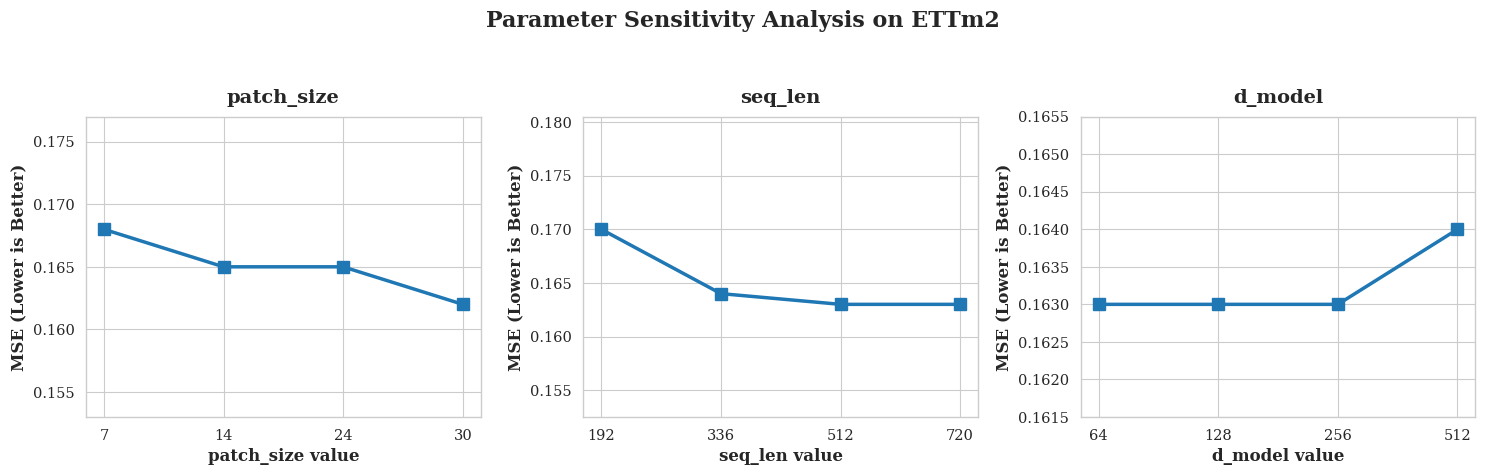

In [31]:
csv_path = "/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/parameter_sensitivity.csv"

df = pd.read_csv(csv_path)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

# ==========================================
# 2. 核心配置：定义我们要画的两个大类
# ==========================================
datasets = ['ETTh1', 'ETTm2']
# 对应在 CSV 里的列索引范围：ETTh1 是 1到4列(即 1:5)，ETTm2 是 5到8列(即 5:9)
col_ranges = [(1, 5), (5, 9)]
# 为两个数据集配置不同的颜色和标记点，以示区分
colors = ['#d62728', '#1f77b4']
markers = ['o', 's']

# ==========================================
# 3. 按数据集循环画图
# ==========================================
for ds_idx, dataset_name in enumerate(datasets):
    # 创建 1行3列 的超宽画布
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # 给整个大图加一个总标题
    fig.suptitle(f'Parameter Sensitivity Analysis on {dataset_name}',
                 fontsize=16, fontweight='bold', y=1.05)

    start_col, end_col = col_ranges[ds_idx]
    color = colors[ds_idx]
    marker = markers[ds_idx]

    # ----------------------------------------
    # 4. 在同一个数据集下，依次读取 3 个参数
    # ----------------------------------------
    # 你的 CSV 共有 6 行，每 2 行是一个参数 (0, 2, 4)
    for p_idx in range(3):
        row_idx = p_idx * 2
        param_name = df.iloc[row_idx, 0]

        # 提取 X 轴并强转为字符串（保证等间距排布）
        x_vals = [str(int(x)) for x in df.iloc[row_idx, start_col:end_col].astype(float).values]
        # 提取 Y 轴 (MSE)
        y_vals = df.iloc[row_idx+1, start_col:end_col].astype(float).values

        ax = axes[p_idx]

        # 绘图
        ax.plot(x_vals, y_vals, marker=marker, markersize=8, linewidth=2.5, color=color)

        # 设置子图的标题和标签
        ax.set_title(param_name, fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel(f'{param_name} value', fontsize=12, fontweight='bold')
        ax.set_ylabel('MSE (Lower is Better)', fontsize=12, fontweight='bold')

        # 压平折线：放宽 Y 轴的显示范围 (缓冲系数为 1.5)
        y_range = max(y_vals) - min(y_vals)
        buffer = y_range * 1.5 if y_range > 0 else 0.02
        ax.set_ylim(min(y_vals) - buffer, max(y_vals) + buffer)

    # ==========================================
    # 5. 自动排版与保存进 Google Drive
    # ==========================================
    plt.tight_layout()

    # 自动保存为高清大图 (bbox_inches='tight' 保证外围大标题不会被裁掉)
    save_filename = f'/content/drive/MyDrive/DSAA5013_G10_Project/Reproduce_Result/sensitivity_ALL_{dataset_name}.png'
    plt.savefig(save_filename, dpi=300, bbox_inches='tight', transparent=False)

    print(f"✅ 成功生成 1x3 组图并保存至: {save_filename}")
    plt.show()